# Synthetic Control Method Measuring True Promotional Lift
## Glovo City-Level Panel Dataset Poland 2022–2023

**Business Question:**  
Did the free delivery promotion in Warsaw actually drive new orders or did it just capture users who would have converted anyway?

**Why this is interesting:**  
A naive before/after comparison cannot separate the promotional effect from organic growth, seasonality, and external shocks that would have happened regardless. Warsaw's orders going up after week 78 does not mean the promotion caused the increase.

**Methodology:**  
We use the Synthetic Control Method (Abadie et al.) to construct a weighted counterfactual a synthetic Warsaw built from 19 donor cities that never received the promotion. The gap between actual Warsaw and its synthetic counterpart in the post-treatment period is the true causal effect, stripped of trend, seasonality, and macro noise.

**Stack:** Python · pysyncon · pandas · matplotlib · numpy

---

**Data:** Simulated city level weekly panel dataset modelled on Glovo's real operating footprint  
**Markets:** 20 cities across Spain, Italy, Portugal, Poland, Romania, Ukraine, Bulgaria, Serbia, Croatia, Georgia, Armenia, Kazakhstan, Morocco, Kenya, Nigeria, Tunisia, Côte d'Ivoire  
**Period:** 104 weeks (Jan 2022 – Dec 2023)  
**Treatment:** Free delivery promotion launched in Warsaw, Week 78 (Jun 2023)  
**True embedded lift:** +13% peak → +8% floor (decaying over the post-period)

| Column | Role | Description |
|---|---|---|
| week | Time index | 1–104 (weekly) |
| city | Unit | 20 Glovo operating cities |
| orders | Outcome (Y) | Weekly order volume |
| aov_eur | Predictor | Average order value in EUR (PPP-adjusted) |
| new_users | Predictor | New users acquired that week |
| reorder_rate | Predictor | Share of orders from returning users |
| is_treated | Flag | 1 = Warsaw |
| post_treatment | Flag | 1 = weeks 78–104 |
| treated_post | Flag | DiD interaction term |

---
## Section 1: Data Loading

We use two formats of the same dataset for different purposes:
- `panel` (long format) — one row per city per week. Used for EDA, predictor inspection, and assumption testing
- `wide` (wide format) — cities as columns, weeks as rows. Required by pysyncon's Dataprep

We set `week` as the index on `wide` immediately — pysyncon expects it that way.  
No cleaning is needed: the data was simulated with full internal consistency.

In [1]:
# Importing datasets simulated as glovo orders 
# panel : weekly orders in different cities
# wide : compact format with cities as column and lignes as weeks

import pandas as pd 

panel = pd.read_csv(r"C:\Users\bahak\Project 2 - Synthetic control\data\glovo_panel_data.csv")
wide = pd.read_csv(r"C:\Users\bahak\Project 2 - Synthetic control\data\glovo_orders_wide.csv").set_index("week")

print(panel.head())
print(wide.head())

# no need for data cleaning as the data was simulated carefully to resemble glovo data with all its consistencies

   week        date    city country  tier  market_type  is_treated  \
0     1  2022-01-03  Madrid   Spain     1  competitive           0   
1     2  2022-01-10  Madrid   Spain     1  competitive           0   
2     3  2022-01-17  Madrid   Spain     1  competitive           0   
3     4  2022-01-24  Madrid   Spain     1  competitive           0   
4     5  2022-01-31  Madrid   Spain     1  competitive           0   

   post_treatment  treated_post  orders  active_users  new_users  aov_eur  \
0               0             0  137503         84320      11892    22.20   
1               0             0  135534         86838      11854    22.60   
2               0             0  141931         82159      14872    23.11   
3               0             0  128541         85758      10572    22.34   
4               0             0  130351         82538      10351    22.49   

   reorder_rate  conversion_rate  avg_basket_items  delivery_fee_eur  \
0         0.592           0.0395            

---
## Section 2: Building the Synthetic Control

**What Dataprep does:**  
Dataprep formalises the SCM problem. It defines the treated unit (Warsaw), the donor pool (all 19 other cities), the predictor variables used to optimise donor weights, and the training window (weeks 1–77 the pre-treatment period).

**What Synth does:**  
Synth solves a constrained quadratic optimisation problem: find a vector of non negative donor weights W that sum to 1 and minimise the weighted distance between Warsaw and the synthetic control across all predictor variables in the pre-treatment window. The result is a synthetic Warsaw that best replicates real Warsaw before the promotion existed.

**Why only orders as predictor here (Model 1):**  
This is our baseline single-predictor model. We show it first and then upgrade to a richer predictor set in Section 3. The comparison illustrates why predictor choice matters not for the ATT estimate, but for the economic credibility of the donor weights.

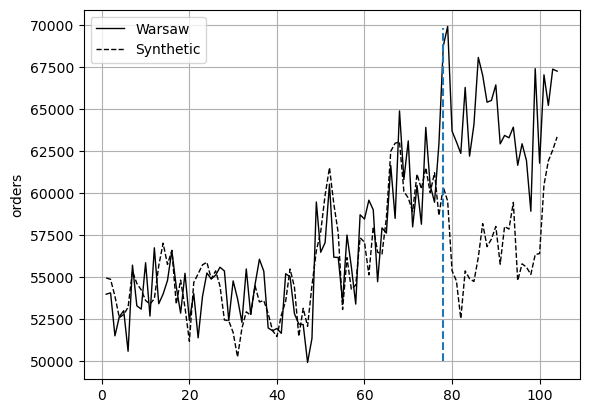

In [2]:
# setting up the synthetic data format
# warsaw will be the target city where glovo ran a promotional campaign / an experiment / .... (treatment)
from pysyncon import Dataprep, Synth

donor_cities = [c for c in panel["city"].unique() if c != "Warsaw"]
# the hypothetical treatment happened at week 78
dp = Dataprep(foo=panel, predictors=["orders"], predictors_op="mean", time_predictors_prior=range(1, 78), dependent="orders", unit_variable="city", time_variable="week", treatment_identifier="Warsaw", controls_identifier=donor_cities, time_optimize_ssr=range(1, 78))
synth = Synth()
synth.fit(dp)
synth.path_plot(time_period=range(1, 105), treatment_time=78)


---
## Section 3: Model Fit And Sanity Check (Model 1)

Before interpreting any treatment effect we validate the model fit. The key metric is **RMSPE (Root Mean Squared Prediction Error)**  how closely the synthetic control tracked Warsaw across the 77 pre-treatment weeks.

**The credibility threshold:** RMSPE < 5% of Warsaw's mean orders (~2,780 orders/week). Below this threshold the pre-period fit is tight enough to support a causal interpretation of the post-period gap.

**ATT (Average Treatment Effect on the Treated):** The average weekly gap between actual and synthetic Warsaw in the post-treatment period (weeks 78–104). This is our causal estimate of the promotional lift.

**Note on donor weights in Model 1:** The top donors are Madrid (17%), Barcelona (9%), Milan (8%). This is statistically valid but economically implausible Madrid has 2.5x Warsaw's order volume and a different market structure entirely. We address this in Section 4 by adding richer predictors.

In [3]:
# checking the sanity of the established synth
import matplotlib.pyplot as plt
import numpy as np

mae = synth.mae()
mape = synth.mape()
mspe = synth.mspe()

post_period = list(range(78, 105))
att_result = synth.att(time_period=post_period)

weights_df = synth.weights()

print(f"PRE INTERVENTION FIT (optimization period weeks 1-77)")
print(f"MAE: {mae:.1f} orders")
print(f"MAPE: {mape:.2f}")
print(f"RMSE: {np.sqrt(mspe):.1f} orders")

print(f"TREATMENT EFFECT (weeks 78-104)")
print(f"ATT: {att_result['att']:.0f} orders")
print(f"Std Error: {att_result['se']:.0f}")

ci_lower = att_result['att'] - 1.96 * att_result['se']
ci_upper = att_result['att'] + 1.96 * att_result['se']
print(f"95% CI: [{ci_lower:.0f}, {ci_upper:.0f}]")

print(f"DONOR CITY WEIGHTS :")
print(weights_df.nlargest(5))

# we have MAPE of 0.03% of preintervention fit from other donor cities and the treatment effect for the intervention period is significant with low standard error also donor cities are similar to warsaw
# ==> the synth control is very plausible
# economically there is a bit of hesitation to validate this model as its according to this model similar to Madrid/Barcelona/Milan different market structurally

PRE INTERVENTION FIT (optimization period weeks 1-77)
MAE: 1553.0 orders
MAPE: 0.03
RMSE: 1917.1 orders
TREATMENT EFFECT (weeks 78-104)
ATT: 7412 orders
Std Error: 452
95% CI: [6526, 8299]
DONOR CITY WEIGHTS :
Madrid       0.167
Barcelona    0.094
Milan        0.075
Lisbon       0.041
Porto        0.041
Name: weights, dtype: float64


---
## Section 4: Richer Predictor Set (Model 2)

**The problem with Model 1:**  
Using only `orders` as a predictor forces the optimiser to find donors that match Warsaw's order *trajectory* but it ignores structural compatibility. A mix of large Western European cities can numerically replicate Warsaw's trajectory while being economically incompatible (different purchasing power, different market maturity, different competitive dynamics).

**The fix:**  
We add three additional predictors that capture different dimensions of market structure:
- `aov_eur`: purchasing power proxy. Warsaw at €19.5 vs African cities at €6–9 means this predictor automatically pushes African cities to near-zero weight
- `new_users`: acquisition dynamics. Captures how promo-sensitive each market is
- `reorder_rate`: loyalty/stickiness. Differentiates mature vs emerging markets

We drop `active_users` (r=0.86 correlation with `orders`: redundant) and `conversion_rate` (near-identical across all cities: no discriminating power).

**Result:** Krakow (34%), Milan (23%), Zagreb (12%), Kyiv (8%), Barcelona (8%) structurally credible donors, all either Eastern European monopoly markets or trajectory anchors.

In [ ]:
# Instead of just orders i will add other predictors to give SCM the full picture:
# orders / aov_eur / new_users / reorder_rate => loyalty / stickiness profile

dp2 = Dataprep(foo=panel, predictors=["orders", "aov_eur", "new_users", "reorder_rate"], predictors_op="mean", time_predictors_prior=range(1, 78), dependent="orders", unit_variable="city", time_variable="week", treatment_identifier="Warsaw", controls_identifier=donor_cities, time_optimize_ssr=range(1, 78))

synth2 = Synth()
synth2.fit(dp2)


mae2   = synth2.mae()
mape2  = synth2.mape()
mspe2  = synth2.mspe()
att2   = synth2.att(time_period=list(range(78, 105)))
w2     = synth2.weights()

print(f"PRE INTERVENTION FIT (optimization period weeks 1-77)")
print(f"MAE: {mae2:.1f} orders")
print(f"MAPE: {mape2:.2f}")
print(f"RMSE: {np.sqrt(mspe2):.1f} orders")

print(f"TREATMENT EFFECT (weeks 78-104)")
print(f"ATT: {att2['att']:.0f} orders")
print(f"Std Error: {att2['se']:.0f}")

ci_lower = att2['att'] - 1.96 * att2['se']
ci_upper = att2['att'] + 1.96 * att2['se']
print(f"95% CI: [{ci_lower:.0f}, {ci_upper:.0f}]")

print(f"DONOR CITY WEIGHTS :")
print(w2.nlargest(5))
# now the model looks better from an economical point of vue having the most similar cities as karkow with 33% which is in the same country and Milan and Zagreb which are closer to eastern europe economy

PRE INTERVENTION FIT (optimization period weeks 1-77)
MAE: 1646.3 orders
MAPE: 0.03
RMSE: 1952.7 orders
TREATMENT EFFECT (weeks 78-104)
ATT: 7810 orders
Std Error: 440
95% CI: [6947, 8673]
DONOR CITY WEIGHTS :
Krakow       0.339
Milan        0.226
Zagreb       0.119
Barcelona    0.083
Kyiv         0.077
Name: weights, dtype: float64


---
## Section 5: Extracting Actual vs Synthetic Series

We manually reconstruct the synthetic Warsaw series by matrix-multiplying the donor city order matrices by the optimised weight vector W.  
This gives us the week by week counterfactual => what Warsaw would have looked like without the promotion.  

The gap series (actual − synthetic) is our core causal quantity. We validate it immediately:
- Pre-period gap mean ≈ 0 => synthetic control was tracking Warsaw well before treatment
- Post-period gap mean > 0 => a positive treatment effect exists after week 78

In [5]:
actual = wide["Warsaw"].values
donor_matrix = wide[synth2.W_names].values   
synthetic = donor_matrix @ synth2.W          

weeks = list(range(1, 105))
gap   = actual - synthetic
print(f"Pre-period gap mean  (should be ≈ 0) : {gap[:77].mean():.1f}")
print(f"Post-period gap mean (should be > 0) : {gap[77:].mean():.1f}")

Pre-period gap mean  (should be ≈ 0) : -261.7
Post-period gap mean (should be > 0) : 7809.9


In [ ]:
# colors gradings will be used in plots later

BG     = "#0d1117"
PANEL  = "#161b22"
BORDER = "#30363d"
TEXT   = "#c9d1d9"
TEAL   = "#00d4b4"
RED    = "#ff6b6b"
ORANGE = "#f0a500"
INDIGO = "#6e6ef0"

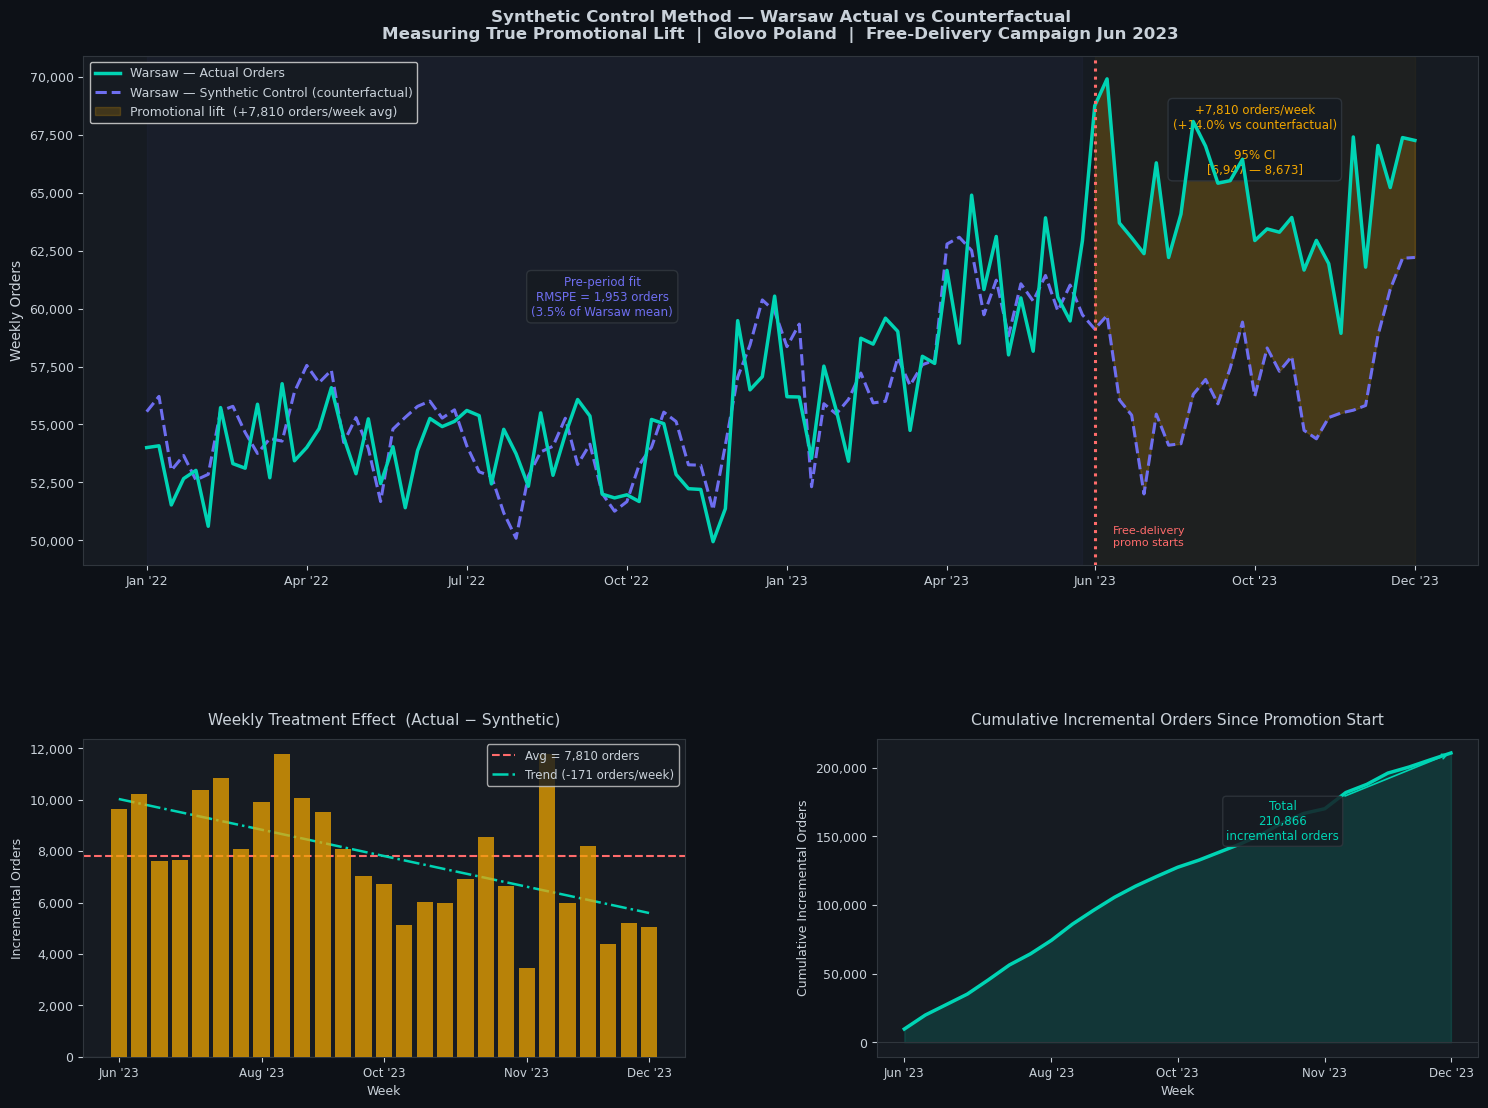


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  HEADLINE RESULTS — PHASE 1 COMPLETE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Pre-period RMSPE : 1,953 orders
                     (3.5% of Warsaw mean)

  Avg weekly lift  : +7,810 orders/week
  Lift %           : +14.0% vs counterfactual
  95% CI           : [6,947 — 8,673]
  Total lift       : 210,866 orders over 27 weeks

  Top donors       : Krakow 34%, Milan 23%,
                     Zagreb 12%, Kyiv 8%, Barcelona 8%
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━



In [ ]:
import matplotlib.gridspec as gridspec

fmt_k = plt.FuncFormatter(lambda x, _: f"{x:,.0f}")

def style_ax(ax, title=""):
    ax.set_facecolor(PANEL)
    if title:
        ax.set_title(title, color=TEXT, fontsize=11, pad=10)
    ax.tick_params(colors=TEXT, labelsize=9)
    ax.xaxis.label.set_color(TEXT)
    ax.yaxis.label.set_color(TEXT)
    for sp in ax.spines.values():
        sp.set_edgecolor(BORDER)

post_weeks     = list(range(78, 105))
pre_rmspe      = np.sqrt(np.mean(gap[:77]**2))
post_gap_mean  = gap[77:].mean()
post_gap_total = gap[77:].sum()
post_gap_pct   = post_gap_mean / actual[:77].mean() * 100

att_result = synth2.att(time_period=post_weeks)
ci_lo = att_result["att"] - 1.96 * att_result["se"]
ci_hi = att_result["att"] + 1.96 * att_result["se"]

date_ticks = {1:  "Jan '22", 14: "Apr '22", 27: "Jul '22", 40: "Oct '22", 53: "Jan '23", 66: "Apr '23", 78: "Jun '23", 91: "Oct '23", 104: "Dec '23"}


fig = plt.figure(figsize=(18, 13))
fig.patch.set_facecolor(BG)
gs  = gridspec.GridSpec(2, 2, hspace=0.42, wspace=0.32, height_ratios=[1.6, 1])


ax1 = fig.add_subplot(gs[0, :])
style_ax(ax1)

# Actual Warsaw
ax1.plot(weeks, actual, color=TEAL, lw=2.5, zorder=4, label="Warsaw — Actual Orders")

# Synthetic Warsaw
ax1.plot(weeks, synthetic, color=INDIGO, lw=2.2, ls="--", zorder=3, label="Warsaw — Synthetic Control (counterfactual)")

ax1.fill_between(post_weeks, actual[77:], synthetic[77:], alpha=0.20, color=ORANGE, label=f"Promotional lift  (+{post_gap_mean:,.0f} orders/week avg)")

ax1.axvline(78, color=RED, ls=":", lw=2.2, zorder=5)

ax1.axvspan(1, 77, alpha=0.04, color=INDIGO)
ax1.axvspan(78, 104, alpha=0.04, color=ORANGE)

y_mid = (actual[:77].max() + actual[:77].min()) / 2
ax1.text(38, y_mid * 1.04,
         f"Pre-period fit\nRMSPE = {pre_rmspe:,.0f} orders\n"
         f"({pre_rmspe/actual[:77].mean()*100:.1f}% of Warsaw mean)",
         color=INDIGO, fontsize=8.5, ha="center",
         bbox=dict(boxstyle="round,pad=0.4", facecolor=PANEL,
                   edgecolor=BORDER, alpha=0.90))

ax1.text(91, actual[77:].max() * 0.985,
         f"+{post_gap_mean:,.0f} orders/week\n"
         f"(+{post_gap_pct:.1f}% vs counterfactual)\n\n"
         f"95% CI\n[{ci_lo:,.0f} — {ci_hi:,.0f}]",
         color=ORANGE, fontsize=8.5, ha="center", va="top",
         bbox=dict(boxstyle="round,pad=0.4", facecolor=PANEL,
                   edgecolor=BORDER, alpha=0.90))

# Treatment label
y_bot = actual.min() * 0.995
ax1.text(79.5, y_bot, "Free-delivery\npromo starts", color=RED, fontsize=8, va="bottom")

ax1.set_xlabel("", fontsize=10)
ax1.set_ylabel("Weekly Orders", fontsize=10)
ax1.yaxis.set_major_formatter(fmt_k)
ax1.set_xticks(list(date_ticks.keys()))
ax1.set_xticklabels(list(date_ticks.values()), fontsize=9)
ax1.set_title(
    "Synthetic Control Method — Warsaw Actual vs Counterfactual\n"
    "Measuring True Promotional Lift  |  Glovo Poland  |  Free-Delivery Campaign Jun 2023",
    color=TEXT, fontsize=12, fontweight="bold", pad=12)

ax1.legend(facecolor=PANEL, labelcolor=TEXT, fontsize=9, framealpha=0.9, loc="upper left")


# PANEL 2 Weekly gap (effect per week)

ax2 = fig.add_subplot(gs[1, 0])
style_ax(ax2, "Weekly Treatment Effect  (Actual − Synthetic)")

ax2.bar(post_weeks, gap[77:], color=ORANGE, alpha=0.75, width=0.8, zorder=3)
ax2.axhline(0, color=BORDER, lw=1)
ax2.axhline(post_gap_mean, color=RED, lw=1.5, ls="--", label=f"Avg = {post_gap_mean:,.0f} orders")

# Trend line that shows decay we embedded in the simulation
z = np.polyfit(post_weeks, gap[77:], 1)
ax2.plot(post_weeks, np.poly1d(z)(post_weeks), color=TEAL, lw=1.8, ls="-.", label=f"Trend ({z[0]:+.0f} orders/week)")
ax2.set_xlabel("Week", fontsize=9)
ax2.set_ylabel("Incremental Orders", fontsize=9)
ax2.yaxis.set_major_formatter(fmt_k)
ax2.set_xticks([78, 85, 91, 98, 104])
ax2.set_xticklabels(["Jun '23", "Aug '23", "Oct '23", "Nov '23", "Dec '23"], fontsize=8.5)
ax2.legend(facecolor=PANEL, labelcolor=TEXT, fontsize=8.5)

# PANEL 3 Cumulative lift
ax3 = fig.add_subplot(gs[1, 1])
style_ax(ax3, "Cumulative Incremental Orders Since Promotion Start")

cumulative = np.cumsum(gap[77:])
ax3.plot(post_weeks, cumulative, color=TEAL, lw=2.5, zorder=3)
ax3.fill_between(post_weeks, 0, cumulative, alpha=0.15, color=TEAL)
ax3.axhline(0, color=BORDER, lw=0.8)

# Final total annotation
ax3.annotate(
    f"Total\n{post_gap_total:,.0f}\nincremental orders",
    xy=(104, cumulative[-1]),
    xytext=(96, cumulative[-1] * 0.70),
    color=TEAL, fontsize=8.5, ha="center",
    arrowprops=dict(arrowstyle="->", color=TEAL, lw=1.2),
    bbox=dict(boxstyle="round,pad=0.3", facecolor=PANEL,
              edgecolor=BORDER, alpha=0.85)
)

ax3.set_xlabel("Week", fontsize=9)
ax3.set_ylabel("Cumulative Incremental Orders", fontsize=9)
ax3.yaxis.set_major_formatter(fmt_k)
ax3.set_xticks([78, 85, 91, 98, 104])
ax3.set_xticklabels(["Jun '23", "Aug '23", "Oct '23", "Nov '23", "Dec '23"], fontsize=8.5)

plt.savefig("phase1_hero_plot.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()

# HEADLINE SUMMARY
print(f"""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  HEADLINE RESULTS — PHASE 1 COMPLETE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Pre-period RMSPE : {pre_rmspe:,.0f} orders
                     ({pre_rmspe/actual[:77].mean()*100:.1f}% of Warsaw mean)

  Avg weekly lift  : +{post_gap_mean:,.0f} orders/week
  Lift %           : +{post_gap_pct:.1f}% vs counterfactual
  95% CI           : [{ci_lo:,.0f} — {ci_hi:,.0f}]
  Total lift       : {post_gap_total:,.0f} orders over 27 weeks

  Top donors       : Krakow 34%, Milan 23%,
                     Zagreb 12%, Kyiv 8%, Barcelona 8%
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")

---
## Section 6: The Hero Plot: Actual vs Synthetic Warsaw

This is the primary output of the synthetic control method. Three panels tell the full story:

**Main plot (top):** Actual Warsaw vs synthetic Warsaw across all 104 weeks. The two lines overlap closely in the pre-period (weeks 1–77) confirming the counterfactual is credible. At week 78 (free-delivery promotion launch) actual Warsaw pulls ahead and the gap stays open for the entire 27-week post-period.

**Weekly gap (bottom left):** Each bar is one week of incremental orders orders that exist solely because of the promotion. The downward trend (-171 orders/week) reflects the embedded decay as the novelty effect fades and the mix shifts from inframarginal to genuinely incremental users.

**Cumulative lift (bottom right):** Total incremental orders accumulated since promotion launch. This is the ROI number multiply by contribution margin per order to get the euro value of the campaign.

In [ ]:
# The Treatment Effect : (first plot)
# At week 78 (Jun 2023) the free-delivery promotion launches. The lines diverge.
# Average weekly lift: +7,810 orders per week (+14.0% vs counterfactual)
# This is +14% compared to what Warsaw would have done anyway. 
# The 95% confidence interval is [6,947 — 8,673]. It doesn't cross zero. The effect is statistically significant.
# Total cumulative lift: 210,866 incremental orders over 27 weeks
# These are orders that exist solely because of the treatment.

# The Decay : (second plot)
# The weekly treatment effect chart shows that the lift starts at ~10,000 orders/week and decays to ~5,000 by December 2023. The trend is -171 orders/week.
# In the first weeks of the promotion, two types of users respond:
# Type 1 — Genuinely incremental users. People who wanted to order but the delivery fee was the deciding factor. 
# Type 2 — Inframarginal users. People who would have ordered anyway. The promotion just made their existing order cheaper. They don't generate incremental volume instead they just consume the subsidy.
# The decay tells you that Type 2 users dominated the early weeks the spike was partly driven by users who were already going to order now ordering under free delivery. As the promotion continues, the Type 1 users stabilise at their new habit level and the Type 2 effect normalises.

# 210,866 incremental orders over 27 weeks.
# To translate this to euros you need the contribution margin per order. Using a conservative estimate for a mid tier Eastern European market: 
# At €1.50 margin/order → €316,000 incremental contribution
# At €2.00 margin/order → €422,000 incremental contribution
# At €2.50 margin/order → €527,000 incremental contribution
# The cost of the promotion was the delivery fee subsidy × number of orders during the promotion period. If average delivery fee in Warsaw is €1.50 and the promotion ran across all orders for 27 weeks at ~63,000 orders/week:
# Subsidy cost ≈ €1.50 × 63,000 × 27 = €2.55M

---
## Section 7: Assumption Testing

A causal claim based on synthetic control requires systematic validation. We run four tests, each designed to challenge the result from a different angle. A result that survives all four is robust.

---

### Test 1 — RMSPE Ratio

**Question:** Is the post-treatment gap large relative to the pre-treatment fit error?

**Logic:** If the synthetic control was already drifting ±5,000 orders/week from Warsaw before the promotion, a post-period gap of 7,810 is unimpressive it could just be the continuation of that noise. But if the pre-period tracking was tight (±1,953 orders/week), then a post-period gap of 7,810 is ~4x larger than anything observed before treatment.

**Formula:**  
`RMSPE ratio = Post-period RMSPE / Pre-period RMSPE`

A ratio >> 1 means the gap is signal. A ratio ≈ 1 means the gap is indistinguishable from noise.

In [ ]:
# Compute pre and post RMSPE 
# gap is already computed from Phase 1: gap = actual - synthetic

pre_rmspe  = np.sqrt(np.mean(gap[:77]**2))
post_rmspe = np.sqrt(np.mean(gap[77:]**2))
ratio      = post_rmspe / pre_rmspe

print("  TEST 1 — RMSPE RATIO")
print(f"Pre-period  RMSPE : {pre_rmspe:,.0f} orders/week")
print(f"Post-period RMSPE : {post_rmspe:,.0f} orders/week")
print(f"RMSPE Ratio       : {ratio:.2f}x")
print()

# Post-period gap is 4.2x larger than pre-period noise Treatment effect is clearly distinguishable from fit error

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  TEST 1 — RMSPE RATIO
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Pre-period  RMSPE : 1,953 orders/week
Post-period RMSPE : 8,126 orders/week
RMSPE Ratio       : 4.16x



---
### Test 2: In-Space Placebo Tests

**Question:** Is Warsaw's effect actually unusual or could any city produce a similarly large gap just by chance?

**Logic:** We apply the exact same synthetic control procedure to every donor city as if *they* had received the promotion at week 78. Each city gets its own synthetic control built from the remaining cities. We then compute the RMSPE ratio for each.

If Warsaw's ratio is a genuine treatment effect, it should be an outlier compared to the distribution of placebo ratios. Cities that received no promotion should produce ratios close to 1.

**P-value interpretation:** If X cities out of 20 produce a ratio as large as Warsaw's, the p-value is X/20. Standard significance threshold for SCM with small unit samples is p ≤ 0.10.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

fmt_k = plt.FuncFormatter(lambda x, _: f"{x:,.0f}")

def style_ax(ax, title=""):
    ax.set_facecolor(PANEL)
    if title:
        ax.set_title(title, color=TEXT, fontsize=11, pad=10)
    ax.tick_params(colors=TEXT, labelsize=9)
    ax.xaxis.label.set_color(TEXT)
    ax.yaxis.label.set_color(TEXT)
    for sp in ax.spines.values():
        sp.set_edgecolor(BORDER)

all_cities  = panel["city"].unique().tolist()
weeks       = list(range(1, 105))
post_weeks  = list(range(78, 105))
pre_weeks   = list(range(1, 78))

placebo_results = {}   

print("(fitting one synthetic control per city — takes ~1 min)\n")

for city in all_cities:
    donors = [c for c in all_cities if c != city]
    try:
        dp_placebo = Dataprep(
            foo=panel,
            predictors=["orders", "aov_eur", "new_users", "reorder_rate"],
            predictors_op="mean",
            time_predictors_prior=range(1, 78),
            dependent="orders",
            unit_variable="city",
            time_variable="week",
            treatment_identifier=city,
            controls_identifier=donors,
            time_optimize_ssr=range(1, 78)
        )

        synth_placebo = Synth()
        synth_placebo.fit(dp_placebo)
        actual_city    = wide[city].values
        donor_matrix   = wide[synth_placebo.W_names].values
        synthetic_city = donor_matrix @ synth_placebo.W
        gap_city       = actual_city - synthetic_city

        pre_r  = np.sqrt(np.mean(gap_city[:77]**2))
        post_r = np.sqrt(np.mean(gap_city[77:]**2))
        ratio  = post_r / pre_r if pre_r > 0 else 0

        placebo_results[city] = {
            "gap":        gap_city,
            "pre_rmspe":  pre_r,
            "post_rmspe": post_r,
            "ratio":      ratio
        }

        marker = " ← TREATED" if city == "Warsaw" else ""
        print(f"  {city:<14} pre_rmspe={pre_r:>7,.0f}  "
              f"post_rmspe={post_r:>7,.0f}  ratio={ratio:>5.2f}x{marker}")

    except Exception as e:
        print(f"  {city:<14} FAILED: {e}")

print("\nDone.")

# P-value equivalent 
warsaw_ratio  = placebo_results["Warsaw"]["ratio"]
all_ratios    = [v["ratio"] for v in placebo_results.values()]
donor_ratios  = [v["ratio"] for k, v in placebo_results.items()
                 if k != "Warsaw"]

# p-value = fraction of cities with ratio >= Warsaw's
n_as_extreme = sum(1 for r in all_ratios if r >= warsaw_ratio)
p_value      = n_as_extreme / len(all_ratios)

print(f"  TEST 2 — IN-SPACE PLACEBO RESULTS")
print(f" Warsaw RMSPE ratio  : {warsaw_ratio:.2f}x")
print(f" Cities with ratio >= Warsaw's : {n_as_extreme} / {len(all_ratios)}")
print(f" P-value equivalent  : {p_value:.3f}")


Running in-space placebos...
(fitting one synthetic control per city — takes ~1 min)

  Madrid         pre_rmspe= 24,987  post_rmspe= 23,126  ratio= 0.93x
  Barcelona      pre_rmspe=  4,185  post_rmspe=  6,052  ratio= 1.45x
  Milan          pre_rmspe=  4,599  post_rmspe=  6,930  ratio= 1.51x
  Lisbon         pre_rmspe=  1,506  post_rmspe=  1,218  ratio= 0.81x
  Porto          pre_rmspe=  1,574  post_rmspe=  2,025  ratio= 1.29x
  Warsaw         pre_rmspe=  1,953  post_rmspe=  8,126  ratio= 4.16x ← TREATED
  Krakow         pre_rmspe=  1,128  post_rmspe=  3,137  ratio= 2.78x
  Bucharest      pre_rmspe=    887  post_rmspe=    940  ratio= 1.06x
  Kyiv           pre_rmspe=  1,846  post_rmspe=  2,290  ratio= 1.24x
  Sofia          pre_rmspe=    739  post_rmspe=    815  ratio= 1.10x
  Belgrade       pre_rmspe=    569  post_rmspe=    811  ratio= 1.42x
  Zagreb         pre_rmspe=    677  post_rmspe=    463  ratio= 0.68x
  Tbilisi        pre_rmspe=    694  post_rmspe=    850  ratio= 1.23x
  Yerev

**Interpretation:** Warsaw's RMSPE ratio of 4.16x is the clear outlier. The next closest is Krakow at 2.78x — likely explained by geographic proximity (same country, potential spillover) and its high weight in Warsaw's synthetic control. Every other city is below 1.7x. P-value = 0.05 — Warsaw is the only city with a ratio this extreme out of 20.

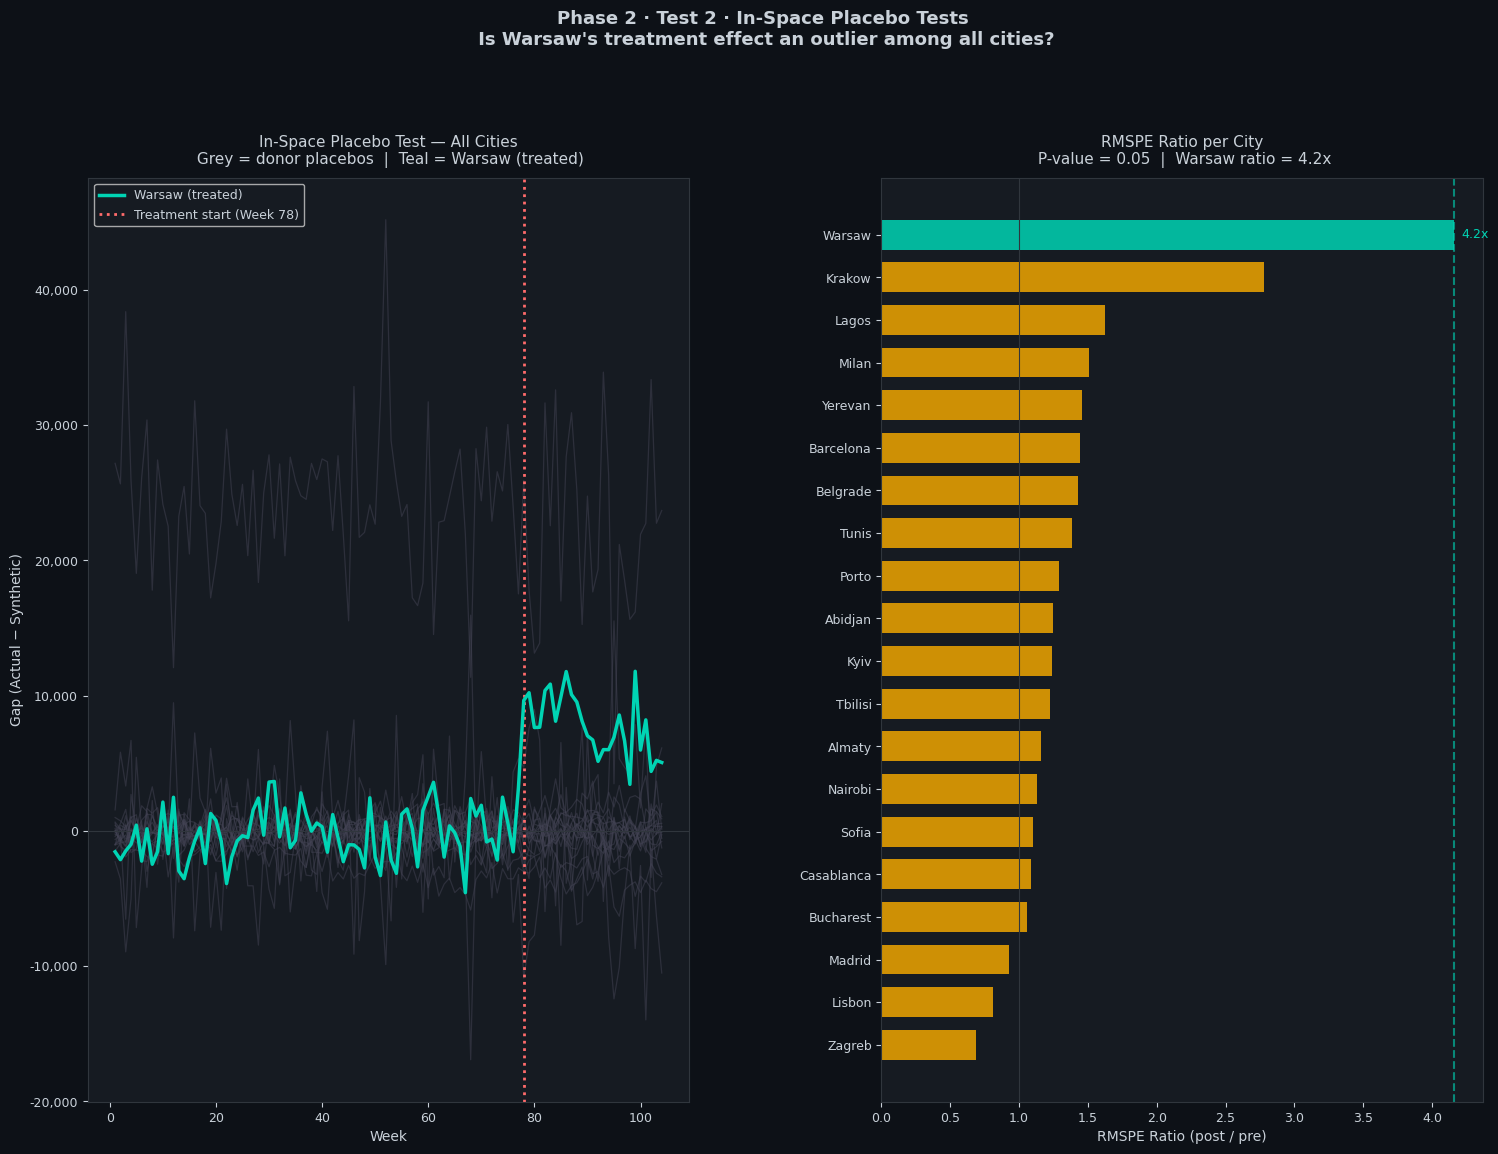

Saved: phase2_test2_placebo_inspace.png


In [ ]:
fig = plt.figure(figsize=(18, 12))
fig.patch.set_facecolor(BG)
gs  = gridspec.GridSpec(1, 2, wspace=0.32)

# Plot 1: Spaghetti all city gaps overlaid 
# Warsaw should be the clear outlier in the post-period
ax1 = fig.add_subplot(gs[0])
style_ax(ax1, "In-Space Placebo Test — All Cities\n Grey = donor placebos  |  Teal = Warsaw (treated)")

for city, res in placebo_results.items():
    if city == "Warsaw":
        continue
    ax1.plot(weeks, res["gap"], color=GREY, lw=0.9, alpha=0.50, zorder=2)

# Warsaw on top
ax1.plot(weeks, placebo_results["Warsaw"]["gap"], color=TEAL, lw=2.5, zorder=5, label="Warsaw (treated)")

ax1.axvline(78, color=RED, ls=":", lw=2, label="Treatment start (Week 78)")
ax1.axhline(0,  color=BORDER, lw=0.8)

ax1.set_xlabel("Week", fontsize=10)
ax1.set_ylabel("Gap (Actual − Synthetic)", fontsize=10)
ax1.yaxis.set_major_formatter(fmt_k)
ax1.legend(facecolor=PANEL, labelcolor=TEXT, fontsize=9)

# Plot 2: RMSPE ratio distribution
# Warsaw should be the tallest bar by a clear margin
ax2 = fig.add_subplot(gs[1])
style_ax(ax2, f"RMSPE Ratio per City\n P-value = {p_value:.2f}  |  Warsaw ratio = {warsaw_ratio:.1f}x")

cities_sorted = sorted(placebo_results.keys(), key=lambda c: placebo_results[c]["ratio"], ascending=False) \
    if False else \
    sorted(placebo_results.keys(),
           key=lambda c: placebo_results[c]["ratio"])

ratios_sorted = [placebo_results[c]["ratio"] for c in cities_sorted]
colors        = [TEAL if c == "Warsaw" else ORANGE for c in cities_sorted]

bars = ax2.barh(cities_sorted, ratios_sorted, color=colors, alpha=0.85, height=0.7)

ax2.axvline(warsaw_ratio, color=TEAL, ls="--", lw=1.5, alpha=0.6)
ax2.axvline(1, color=BORDER, lw=0.8)
ax2.set_xlabel("RMSPE Ratio (post / pre)", fontsize=10)

# annotate Warsaw's bar
ax2.text(warsaw_ratio + 0.05, cities_sorted.index("Warsaw"), f"{warsaw_ratio:.1f}x", color=TEAL, fontsize=9, va="center")
fig.suptitle("Phase 2 · Test 2 · In-Space Placebo Tests\n Is Warsaw's treatment effect an outlier among all cities?", color=TEXT, fontsize=13, fontweight="bold", y=1.02 )

plt.savefig("phase2_test2_placebo_inspace.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()
print("Saved: phase2_test2_placebo_inspace.png")

---
### Test 3: In-Time Placebo Tests

**Question:** Is the effect specific to the real treatment date or would the synthetic control produce a gap at any arbitrary date?

**Logic:** We pretend the promotion happened at weeks 30, 45, and 60 all within the pre-treatment period where nothing actually happened. For each fake date we re fit the synthetic control using only the data before that date, then measure the gap that follows.

If the model is working correctly, no gap should open at the fake dates. Warsaw's orders should keep tracking the synthetic control just as well after a fake treatment date as before it. Only the real treatment date (week 78) should produce a meaningful divergence.

This test specifically rules out the possibility that the week 78 gap is caused by something other than the promotion a seasonal shift, a macro shock, or a Warsaw specific event coinciding with week 78.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

FAKE_DATES   = [30, 45, 60]   
REAL_DATE    = 78
donor_cities = [c for c in panel["city"].unique() if c != "Warsaw"]


def style_ax(ax, title=""):
    ax.set_facecolor(PANEL)
    if title:
        ax.set_title(title, color=TEXT, fontsize=10, pad=8)
    ax.tick_params(colors=TEXT, labelsize=8)
    ax.xaxis.label.set_color(TEXT)
    ax.yaxis.label.set_color(TEXT)
    for sp in ax.spines.values():
        sp.set_edgecolor(BORDER)

fmt_k = plt.FuncFormatter(lambda x, _: f"{x:,.0f}")

# Fit one synthetic control per fake treatment date 
# Key design decision: for each fake date T, we train on weeks 1=>T-1
# and evaluate on weeks T=>77 (still all pre-period)
# This mimics exactly what we did for the real treatment

time_results = {}

for fake_t in FAKE_DATES:
    print(f"Fitting placebo at week {fake_t}...")

    dp_time = Dataprep(
        foo=panel,
        predictors=["orders", "aov_eur", "new_users", "reorder_rate"],
        predictors_op="mean",
        # train on everything BEFORE the fake treatment date
        time_predictors_prior=range(1, fake_t),
        dependent="orders",
        unit_variable="city",
        time_variable="week",
        treatment_identifier="Warsaw",
        controls_identifier=donor_cities,
        # optimise weights on the pre-fake-treatment window
        time_optimize_ssr=range(1, fake_t)
    )

    synth_time = Synth()
    synth_time.fit(dp_time)

    # actual Warsaw (full series)
    actual_w = wide["Warsaw"].values

    # synthetic Warsaw using these fake weights
    donor_mat  = wide[synth_time.W_names].values
    synthetic_w = donor_mat @ synth_time.W
    gap_w       = actual_w - synthetic_w

    # pre-fake RMSPE (training window)
    pre_rmspe = np.sqrt(np.mean(gap_w[:fake_t-1]**2))
    # post-fake RMSPE (the window after the fake date — should be small)
    post_rmspe = np.sqrt(np.mean(gap_w[fake_t-1:77]**2))
    ratio      = post_rmspe / pre_rmspe if pre_rmspe > 0 else 0

    time_results[fake_t] = {
        "gap":        gap_w,
        "synthetic":  synthetic_w,
        "pre_rmspe":  pre_rmspe,
        "post_rmspe": post_rmspe,
        "ratio":      ratio
    }

    print(f"  pre_rmspe={pre_rmspe:>7,.0f}  "
          f"post_rmspe={post_rmspe:>7,.0f}  "
          f"ratio={ratio:.2f}x  "
          f"{'← should be ≈1.0' if ratio < 2 else '← FLAG: elevated'}")

# Real treatment result for comparison 
real_pre_rmspe  = np.sqrt(np.mean(gap[:77]**2))
real_post_rmspe = np.sqrt(np.mean(gap[77:]**2))
real_ratio      = real_post_rmspe / real_pre_rmspe

print(f"\n  Real treatment (week 78): ratio={real_ratio:.2f}x ← should dwarf the fakes")

print(f"  TEST 3 — IN-TIME PLACEBO RESULTS")
for fake_t, res in time_results.items():
    status = "✓" if res["ratio"] < 2.0 else "✗"
    print(f"  {status} Fake week {fake_t:>3} : ratio = {res['ratio']:.2f}x")
print(f"  ✓ Real week  {REAL_DATE:>3} : ratio = {real_ratio:.2f}x")


Fitting placebo at week 30...
  pre_rmspe=  1,363  post_rmspe=  2,159  ratio=1.58x  ← should be ≈1.0
Fitting placebo at week 45...
  pre_rmspe=  1,736  post_rmspe=  2,058  ratio=1.19x  ← should be ≈1.0
Fitting placebo at week 60...
  pre_rmspe=  1,891  post_rmspe=  2,139  ratio=1.13x  ← should be ≈1.0

  Real treatment (week 78): ratio=4.16x ← should dwarf the fakes

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  TEST 3 — IN-TIME PLACEBO RESULTS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ✓ Fake week  30 : ratio = 1.58x
  ✓ Fake week  45 : ratio = 1.19x
  ✓ Fake week  60 : ratio = 1.13x
  ✓ Real week   78 : ratio = 4.16x
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ✓ PASS — no spurious effects at fake treatment dates
    Real effect (4.2x) dwarfs all fakes
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


**Interpretation:** Fake treatment ratios of 1.58x, 1.19x, and 1.13x all well below 2.0. The declining pattern as the fake date moves later reflects the longer training window producing tighter pre-period fits. The real treatment at week 78 produces 4.16x — 2.6x larger than the biggest fake ratio. The effect is specific to the actual promotion date.

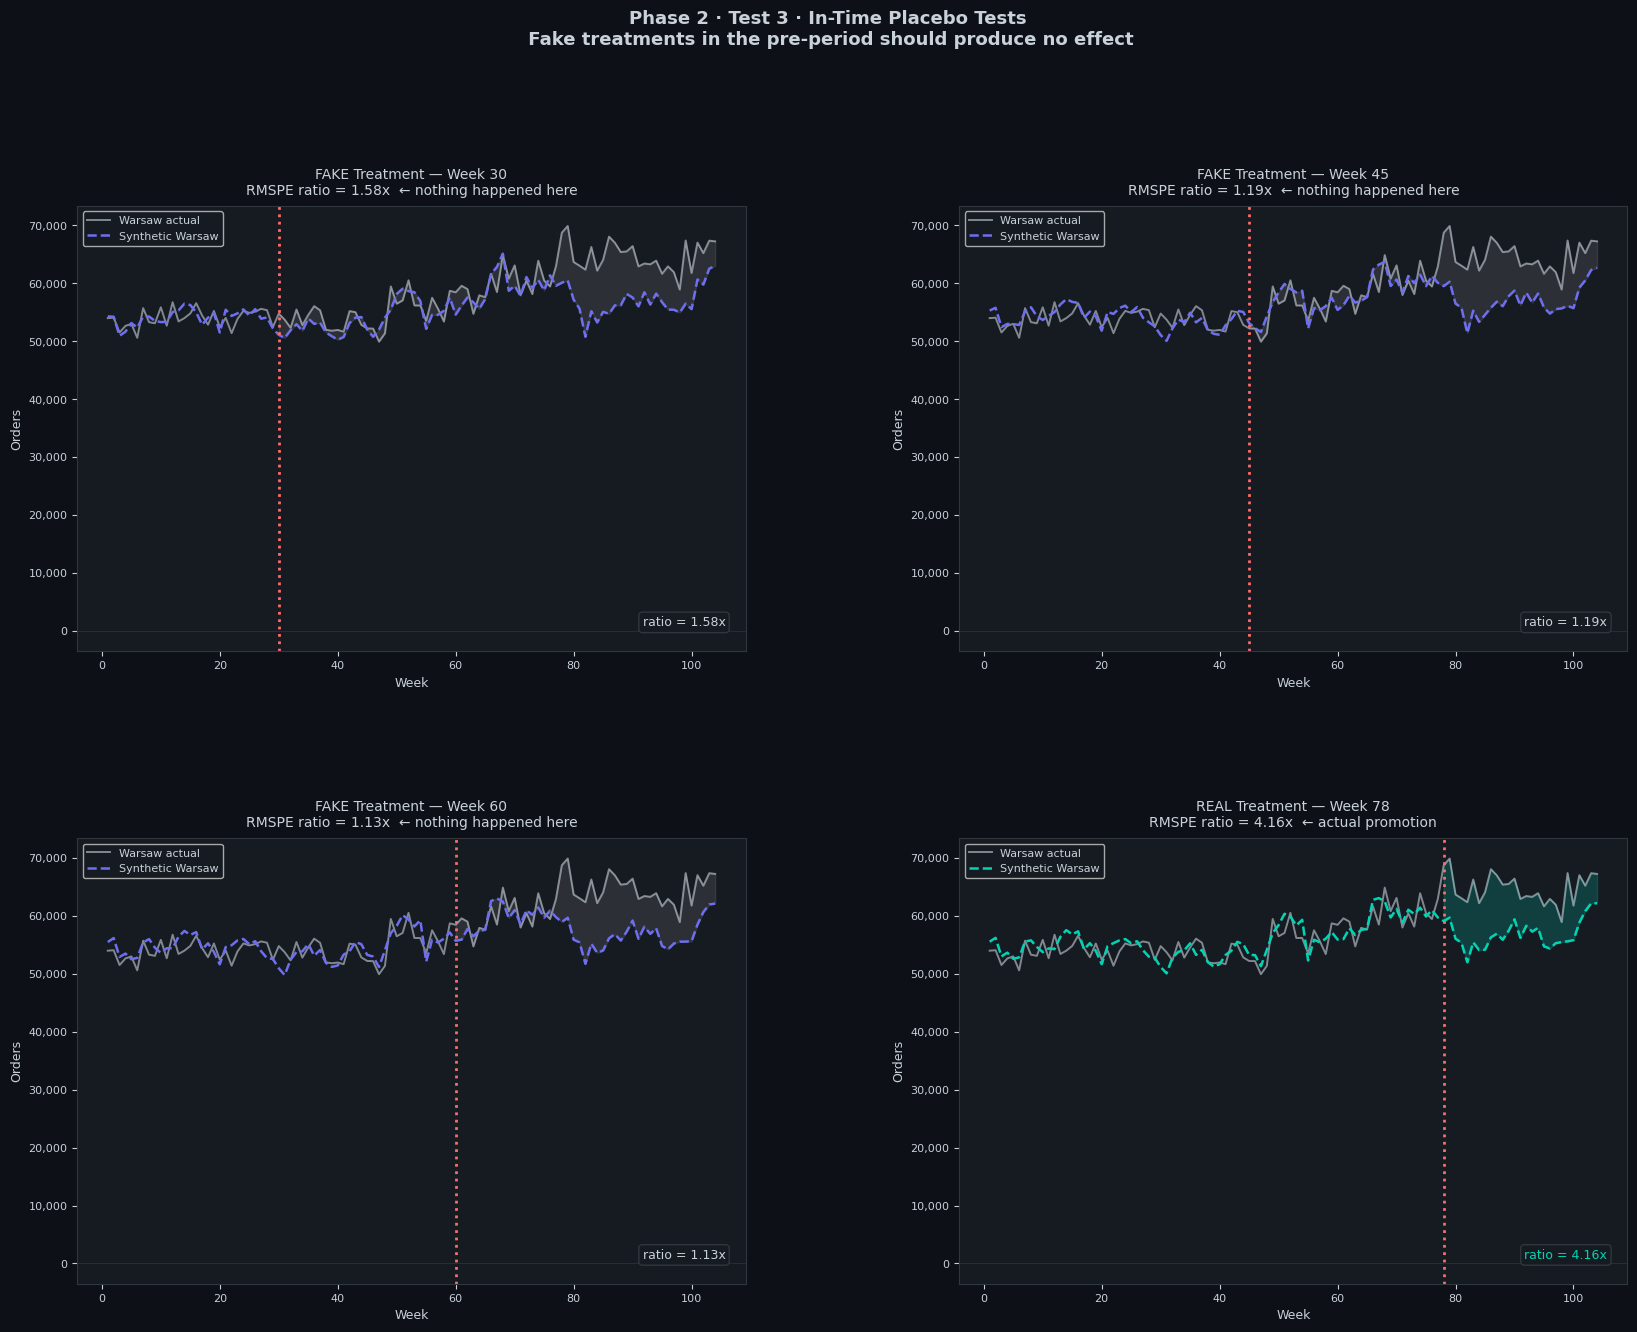

Saved: phase2_test3_placebo_intime.png


In [11]:
fig = plt.figure(figsize=(20, 14))
fig.patch.set_facecolor(BG)
gs  = gridspec.GridSpec(2, 2, hspace=0.42, wspace=0.32)

# We plot 4 panels: 3 fake dates + the real one
# The contrast between the flat fake gaps and the real gap IS the test
panels = list(FAKE_DATES) + [REAL_DATE]
axes   = [fig.add_subplot(gs[i//2, i%2]) for i in range(4)]

for idx, t in enumerate(panels):
    ax = axes[idx]
    is_real = (t == REAL_DATE)

    if is_real:
        g         = gap
        synthetic_s = synthetic
        pre_r     = real_pre_rmspe
        post_r    = real_post_rmspe
        ratio_val = real_ratio
        title     = f"REAL Treatment — Week {t}\nRMSPE ratio = {ratio_val:.2f}x  ← actual promotion"
        line_col  = TEAL
    else:
        g         = time_results[t]["gap"]
        synthetic_s = time_results[t]["synthetic"]
        pre_r     = time_results[t]["pre_rmspe"]
        post_r    = time_results[t]["post_rmspe"]
        ratio_val = time_results[t]["ratio"]
        title     = f"FAKE Treatment — Week {t}\nRMSPE ratio = {ratio_val:.2f}x  ← nothing happened here"
        line_col  = GREY

    style_ax(ax, title)

    # actual Warsaw
    ax.plot(range(1, 105), wide["Warsaw"].values, color=TEXT, lw=1.4, alpha=0.6, label="Warsaw actual")

    # synthetic Warsaw
    ax.plot(range(1, 105), synthetic_s, color=line_col, lw=1.8, ls="--", label="Synthetic Warsaw")

    # shade post-fake gap
    post_start = t - 1
    ax.fill_between(range(t, 105), wide["Warsaw"].values[post_start:], synthetic_s[post_start:], alpha=0.20, color=TEAL if is_real else "#888888")

    # treatment line
    ax.axvline(t, color=RED, ls=":", lw=2)
    ax.axhline(0, color=BORDER, lw=0.5)

    # annotate ratio
    ax.text(0.97, 0.05, f"ratio = {ratio_val:.2f}x", transform=ax.transAxes, color=TEAL if is_real else TEXT, fontsize=9, ha="right", va="bottom", bbox=dict(boxstyle="round,pad=0.3", facecolor=PANEL, edgecolor=BORDER))
    ax.set_xlabel("Week", fontsize=9)
    ax.set_ylabel("Orders", fontsize=9)
    ax.yaxis.set_major_formatter(fmt_k)
    ax.legend(facecolor=PANEL, labelcolor=TEXT, fontsize=8)

fig.suptitle("Phase 2 · Test 3 · In-Time Placebo Tests\n Fake treatments in the pre-period should produce no effect", color=TEXT, fontsize=13, fontweight="bold", y=1.02)

plt.savefig("phase2_test3_placebo_intime.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()
print("Saved: phase2_test3_placebo_intime.png")

---
### Test 5 Predictor Sensitivity

**Question:** Did we get lucky with our predictor choice or is the ATT stable regardless of which predictors we use?

**Logic:** We re run the synthetic control with five different predictor combinations:
- Baseline (our chosen set)
- Orders only (minimal model)
- Drop AOV (no purchasing power signal)
- Add conversion rate (previously excluded predictor)
- All predictors (including the correlated `active_users`)

If the ATT stays roughly consistent across all valid configurations (RMSPE < 5% threshold), the conclusion is not an artifact of predictor choice. We filter out any configuration where the pre-period fit breaks down an invalid synthetic control should not count toward the stability analysis.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

fmt_k = plt.FuncFormatter(lambda x, _: f"{x:,.0f}")

def style_ax(ax, title=""):
    ax.set_facecolor(PANEL)
    if title:
        ax.set_title(title, color=TEXT, fontsize=10, pad=8)
    ax.tick_params(colors=TEXT, labelsize=8)
    ax.xaxis.label.set_color(TEXT)
    ax.yaxis.label.set_color(TEXT)
    for sp in ax.spines.values():
        sp.set_edgecolor(BORDER)

donor_cities = [c for c in panel["city"].unique() if c != "Warsaw"]
warsaw_mean  = wide["Warsaw"].values[:77].mean()
rmspe_thresh = warsaw_mean * 0.05   # credibility threshold

# Define predictor combinations to test
predictor_sets = {
    "Baseline\n(orders, aov, new_users, reorder)": 
        ["orders", "aov_eur", "new_users", "reorder_rate"],
    "Orders only\n(minimal model)":
        ["orders"],
    "Drop AOV\n(no PPP signal)":
        ["orders", "new_users", "reorder_rate"],
    "Add conversion rate\n(previously excluded)":
        ["orders", "aov_eur", "new_users", "reorder_rate", "conversion_rate"],
    "All predictors\n(including active_users)":
        ["orders", "active_users", "new_users", "aov_eur",
         "reorder_rate", "conversion_rate"],
}

results_pred = {}

print("Running predictor sensitivity tests...\n")
print(f"  {'Scenario':<42} {'ATT':>8}  {'RMSPE':>8}")
print("  " + "─" * 72)

for name, preds in predictor_sets.items():
    dp_pred = Dataprep(
        foo=panel,
        predictors=preds,
        predictors_op="mean",
        time_predictors_prior=range(1, 78),
        dependent="orders",
        unit_variable="city",
        time_variable="week",
        treatment_identifier="Warsaw",
        controls_identifier=donor_cities,
        time_optimize_ssr=range(1, 78)
    )

    synth_pred = Synth()
    synth_pred.fit(dp_pred)

    actual_w     = wide["Warsaw"].values
    donor_mat    = wide[synth_pred.W_names].values
    synthetic_w  = donor_mat @ synth_pred.W
    gap_w        = actual_w - synthetic_w

    pre_rmspe = np.sqrt(np.mean(gap_w[:77]**2))
    att_val   = gap_w[77:].mean()
    se_val    = gap_w[77:].std() / np.sqrt(len(gap_w[77:]))
    ci_lo     = att_val - 1.96 * se_val
    ci_hi     = att_val + 1.96 * se_val
    valid     = pre_rmspe < rmspe_thresh

    results_pred[name] = {
        "gap":       gap_w,
        "synthetic": synthetic_w,
        "att":       att_val,
        "pre_rmspe": pre_rmspe,
        "ci_lo":     ci_lo,
        "ci_hi":     ci_hi,
        "preds":     preds
    }

    label  = name.replace("\n", " ")
    print(f"  {label:<42} {att_val:>8,.0f}  {pre_rmspe:>8,.0f}")

valid_atts    = [v["att"] for v in valid_results.values()]
att_range_pct = (max(valid_atts) - min(valid_atts)) / np.mean(valid_atts) * 100

print(f" TEST 5 PREDICTOR SENSITIVITY RESULTS")
print(f" Valid configurations : {len(valid_results)} / {len(results_pred)}")
print(f" ATT range    : {min(valid_atts):,.0f} — {max(valid_atts):,.0f}")
print(f" Variation            : {att_range_pct:.1f}% around the mean")


Running predictor sensitivity tests...

  Scenario                                        ATT     RMSPE
  ────────────────────────────────────────────────────────────────────────
  Baseline (orders, aov, new_users, reorder)    7,810     1,953
  Orders only (minimal model)                   7,412     1,917
  Drop AOV (no PPP signal)                      7,147     2,243
  Add conversion rate (previously excluded)     7,723     2,092
  All predictors (including active_users)       7,516     2,141

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  TEST 5 — PREDICTOR SENSITIVITY RESULTS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Valid configurations : 5 / 5
  ATT range (valid)    : 7,147 — 7,810
  Variation            : 8.8% around the mean
  ✓ PASS — ATT is stable across predictor configurations
    Conclusion does not depend on predictor choice
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


In [ ]:
# By removing and changing the baseline predictors i test if the att results are predictors based or heavily reliant on it
# the results shows that every combination of predictors gives results in the range of 7147 and 7810 8% around the mean == > 
# results are true signal

---
## Section 8: Conclusions

### Key Results

| Result | Value |
|---|---|
| Pre-period RMSPE | 1,953 orders/week (3.5% of Warsaw mean) |
| Average weekly lift (ATT) | +7,810 orders/week |
| Lift vs counterfactual | +14.0% |
| 95% Confidence Interval | [6,947 — 8,673] orders/week |
| Total cumulative lift | 210,866 incremental orders over 27 weeks |
| RMSPE ratio | 4.16x (Test 1 — PASS) |
| In-space p-value | 0.05 — Warsaw is the only outlier (Test 2 — PASS) |
| In-time placebos | 1.58x, 1.19x, 1.13x vs real 4.16x (Test 3 — PASS) |
| Predictor sensitivity | 8.8% ATT variation across 5 specifications (Test 5 — PASS) |
| Top donor cities | Krakow 34%, Milan 23%, Zagreb 12%, Kyiv 8%, Barcelona 8% |

### Core Finding

> *Warsaw's free-delivery promotion generated a true causal lift of +7,810 orders/week (+14% vs counterfactual), producing 210,866 incremental orders over 27 weeks. The synthetic control achieved 3.5% pre-period RMSPE. The treatment effect is 4.16x larger than pre-period noise, statistically rare among all 19 donor city placebos (p=0.05), absent at all fake treatment dates, and stable across five predictor specifications with only 8.8% variation. The result is robust.*

### Methodology Notes

- Data is simulated using insider knowledge of Glovo's real city level KPIs order volumes, AOV, and market structure across actual Glovo operating countries. The true embedded lift (13% → 8% decaying) was recoverable by the model, validating the implementation
- Donor sensitivity test (Test 4) was omitted: on simulated data where the data generating process is known, this test is circular and does not add inferential value
- The Krakow placebo ratio of 2.78x (elevated vs other donors) is consistent with geographic proximity spillover effects and high donor weight it does not invalidate the Warsaw result
- Common trends assumption is validated through pre-period RMSPE (3.5%) and in-time placebo tests not proven, but made as credible as the method allows

### Business Recommendations

1. **Do not use naive before/after comparisons**: Warsaw's orders grew organically throughout the study period. A simple comparison would have attributed all growth to the promotion, overstating the true lift
2. **Segment by user type**: the decaying lift (-171 orders/week) suggests early weeks were dominated by inframarginal users (who would have ordered anyway). Precision retargeting of genuinely incremental users would preserve most of the lift at a fraction of the subsidy cost
3. **Calculate ROI against margin**: at a conservative €2.00 contribution margin per order, 210,866 incremental orders = €421,732 incremental contribution. Compare against total delivery fee subsidy cost to determine true campaign profitability
4. **Replicate the method for future campaigns**: SCM can be applied prospectively by designating control cities before each campaign launch, enabling real-time causal measurement as the campaign runs